In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit, cross_validate
from src.ElectricSequentialRegressor import ElectricSequentialRegressor
from scipy.stats import randint, uniform
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, r2_score, make_scorer
from src.Utils import mse_column_score, plot_performance_analysis, shifted_mape
import joblib

<h2>Lectura y Tratamiento de Datos</h2>

In [2]:
X = pd.read_csv('../dataset/dataset_in.txt', index_col=0).drop(columns=['P2', 'Q2'])
Y = pd.read_csv('../dataset/dataset_out.txt', index_col=0).loc[:, ['PERD', 'QGEN7']]
#FILTRAR DATOS ERRÓNEOS (PÉRDIDAS NEGATIVAS)
mask = Y['PERD'] >= 0
X = X[mask]
Y = Y[mask]

**Validación por Retención (Tratamiento como Serie Temporal)**

In [3]:
# VALIDACIÓN POR RETENCIÓN PARA EVALUACIÓN FINAL DEL MEJOR MODELO
n_samples = X.shape[0]
train_size = int(n_samples * 0.8)
x_train, y_train = X[:train_size], Y[:train_size]
x_test, y_test = X[train_size:], Y[train_size:]

<h2>Búsqueda Aleatoria de Hiperparámetros</h2>

In [4]:
random_model = ElectricSequentialRegressor(RandomForestRegressor(n_jobs=1, random_state=42), RandomForestRegressor(n_jobs=1, random_state=42))
random_grid = {
    'estimator1__n_estimators': randint(30, 101),
    'estimator1__max_depth': randint(10, 51),
    'estimator1__min_samples_split': randint(2, 21),
    'estimator1__max_features': uniform(0.1, 0.9),
    'estimator2__n_estimators': randint(80, 251),
    'estimator2__max_depth': randint(10, 51),
    'estimator2__min_samples_split': randint(2, 21),
    'estimator2__max_features': uniform(0.1, 0.9)
}
random_scoring = {
    'mse_global': 'neg_mean_squared_error',
    'mse_perd': make_scorer(mse_column_score, col_idx=0, greater_is_better=False),
    'mse_qgen7': make_scorer(mse_column_score, col_idx=1, greater_is_better=False),
}
random_search = RandomizedSearchCV(random_model, random_grid, n_iter=30,
                                   cv=TimeSeriesSplit(n_splits=3), scoring=random_scoring, refit='mse_global',
                                   n_jobs=-1, verbose=2, random_state=42, return_train_score=True)

In [5]:
random_search.fit(x_train, y_train)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


,estimator,ElectricSeque...dom_state=42))
,param_distributions,"{'estimator1__max_depth': <scipy.stats....001F7788B4810>, 'estimator1__max_features': <scipy.stats....001F7788B57D0>, 'estimator1__min_samples_split': <scipy.stats....001F7788B51D0>, 'estimator1__n_estimators': <scipy.stats....001F777DB1A50>, ...}"
,n_iter,30
,scoring,"{'mse_global': 'neg_mean_squared_error', 'mse_perd': make_scorer(m...t', col_idx=0), 'mse_qgen7': make_scorer(m...t', col_idx=1)}"
,n_jobs,-1
,refit,'mse_global'
,cv,TimeSeriesSpl...est_size=None)
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [6]:
# PREDICCIONES DEL MEJOR MODELO CON VALORES DEL "FUTURO" X_TEST, YA QUE LO TRATAMOS COMO SERIE TEMPORAL
best_random_model = random_search.best_estimator_
random_predictions = best_random_model.predict(x_test)
print('MSE: ' + str(random_search.best_score_))
random_results = pd.DataFrame(random_search.cv_results_)
random_results.loc[:, ['mean_test_mse_global', 'mean_test_mse_perd', 'mean_test_mse_qgen7']]

MSE: -0.27321464542300294


,mean_test_mse_global,mean_test_mse_perd,mean_test_mse_qgen7
0,-0.328223,-0.656122,-0.000324
1,-0.421320,-0.842314,-0.000325
2,-0.417294,-0.834238,-0.000349
3,-0.342561,-0.684798,-0.000325
4,-0.287392,-0.574318,-0.000466
5,-0.287017,-0.573715,-0.000319
6,-0.378275,-0.756219,-0.000331
7,-0.298011,-0.595695,-0.000327
8,-0.300444,-0.600434,-0.000453
9,-0.289799,-0.579274,-0.000324


In [7]:
random_MAE = mean_absolute_error(y_test, random_predictions, multioutput='raw_values')
random_MAPE = mean_absolute_percentage_error(y_test, random_predictions, multioutput='raw_values')
#DESPLAZAMIENTO PARA EVITAR DIVISIÓN POR VALORES CERCANO A 0. CONSECUENCIA: MAPE ALGO OPTIMISTA
random_MAPE_shifted = mean_absolute_percentage_error(y_test + 1.0, random_predictions + 1.0, multioutput='raw_values')
random_R2 = r2_score(y_test, random_predictions, multioutput='raw_values')

In [8]:
# RESULTADOS CON MAPE DESPLAZADO
random_data_score_shifted = np.vstack([random_MAE, random_MAPE_shifted, random_R2])
evaluations_shifted = pd.DataFrame(random_data_score_shifted, columns=['PERD', 'QGEN7'], index=['MAE', 'MAPE', 'R2'])
evaluations_shifted

,PERD,QGEN7
MAE,0.494735,0.006523
MAPE,0.055864,0.006137
R2,0.948376,0.882999


In [9]:
# RESULTADOS SIN DESPLAZAMIENTO
random_data_score = np.vstack([random_MAE, random_MAPE, random_R2])
evaluations = pd.DataFrame(random_data_score, columns=['PERD', 'QGEN7'], index=['MAE', 'MAPE', 'R2'])
evaluations

,PERD,QGEN7
MAE,0.494735,6.523493e-03
MAPE,0.065082,9.293434e+12
R2,0.948376,8.829990e-01


**Validación Cruzada para Contrastación de Resultados**

In [10]:
random_search.best_params_

{'estimator1__max_depth': 20,
 'estimator1__max_features': np.float64(0.9420714947988528),
 'estimator1__min_samples_split': 5,
 'estimator1__n_estimators': 67,
 'estimator2__max_depth': 49,
 'estimator2__max_features': np.float64(0.6457861536936309),
 'estimator2__min_samples_split': 4,
 'estimator2__n_estimators': 191}

In [11]:
evaluate_model_shifted = ElectricSequentialRegressor(RandomForestRegressor(max_features= 0.94, max_depth=20, min_samples_split=5, n_estimators=67, n_jobs=1, random_state=42),
                                             RandomForestRegressor(max_depth=49, max_features=0.64, min_samples_split=4, n_estimators=191, n_jobs=1, random_state=42))
evaluate_scoring_shifted = { # EVALUACIÓN CON DESPLAZAMIENTO EN MAPE
    'mse': 'neg_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'mape': make_scorer(shifted_mape, greater_is_better=False),
    'r2': 'r2'
}
evaluate_results_shifted = cross_validate(evaluate_model_shifted, X, Y, scoring=evaluate_scoring_shifted, cv=TimeSeriesSplit(n_splits=5), n_jobs=-1)
print('MSE: ' + str(-evaluate_results_shifted['test_mse'].mean()))
print('MAE: ' + str(-evaluate_results_shifted['test_mae'].mean()))
print('MAPE: ' + str(-evaluate_results_shifted['test_mape'].mean()))
print('R2: ' + str(evaluate_results_shifted['test_r2'].mean()))

MSE: 0.28048695210409375
MAE: 0.2654685771158158
MAPE: 0.03282421091581774
R2: 0.9178583146622182


In [12]:
evaluate_model = ElectricSequentialRegressor(RandomForestRegressor(max_features= 0.94, max_depth=20, min_samples_split=5, n_estimators=67, n_jobs=1, random_state=42),
                                             RandomForestRegressor(max_depth=49, max_features=0.64, min_samples_split=4, n_estimators=191, n_jobs=1, random_state=42))
evaluate_scoring = { # EVALUACIÓN SIN DESPLAZAMIENTO EN MAPE
    'mse': 'neg_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'mape': 'neg_mean_absolute_percentage_error',
    'r2': 'r2'
}
evaluate_results = cross_validate(evaluate_model, X, Y, scoring=evaluate_scoring, cv=TimeSeriesSplit(n_splits=5), n_jobs=-1)
print('MSE: ' + str(-evaluate_results['test_mse'].mean()))
print('MAE: ' + str(-evaluate_results['test_mae'].mean()))
print('MAPE: ' + str(-evaluate_results['test_mape'].mean()))
print('R2: ' + str(evaluate_results['test_r2'].mean()))

MSE: 0.28048695210409375
MAE: 0.2654685771158158
MAPE: 4534564726618.44
R2: 0.9178583146622182


<h2>Figuras de Rendimiento del Mejor Modelo</h2>

In [13]:
joblib.dump(best_random_model, '../models/ESR_RandomForest.pkl')

['../models/ESR_RandomForest.pkl']

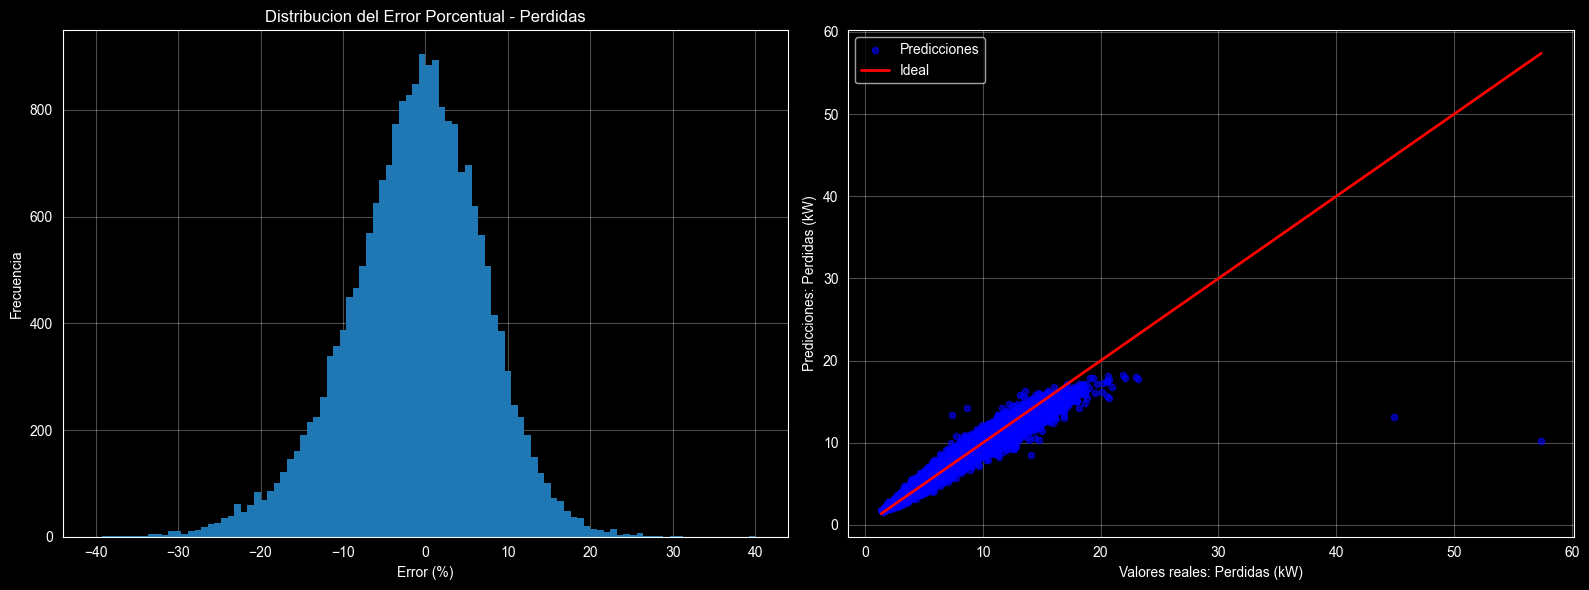

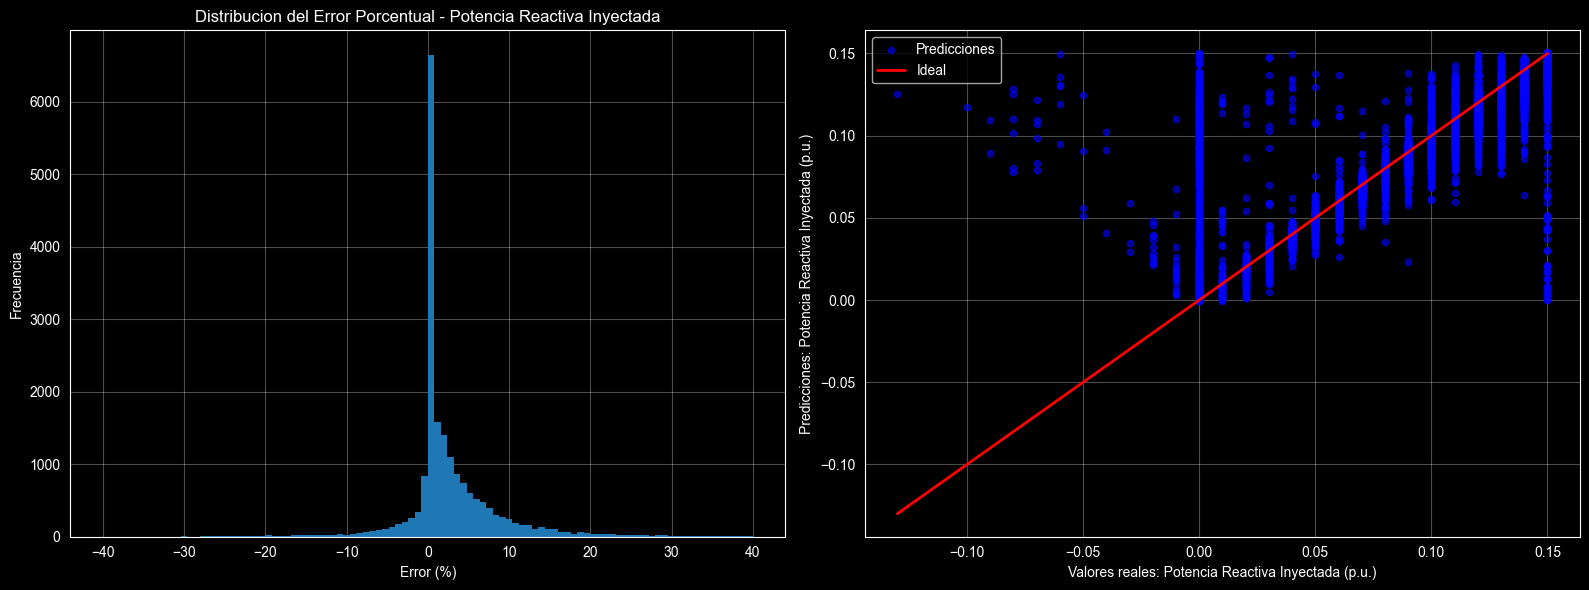

In [14]:
plot_performance_analysis(
    y_test['PERD'],
    random_predictions[:, -2],
    variable_name="Perdidas",
    unit_label="kW",
    path='../figures/RandomForest/ESR_RandomForest_Perd.png'
)

plot_performance_analysis(
    y_test['QGEN7'],
    random_predictions[:, -1],
    variable_name="Potencia Reactiva Inyectada",
    unit_label="p.u.",
    path='../figures/RandomForest/ESR_RandomForest_QGEn.png'
)